<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#WoS-simulation-with-ML" data-toc-modified-id="WoS-simulation-with-ML-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>WoS simulation with ML</a></span></li><li><span><a href="#Play-with-polynomials" data-toc-modified-id="Play-with-polynomials-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Play with polynomials</a></span></li><li><span><a href="#Distribution-base-on-angle" data-toc-modified-id="Distribution-base-on-angle-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Distribution base on angle</a></span><ul class="toc-item"><li><span><a href="#Dimension-$d=2$" data-toc-modified-id="Dimension-$d=2$-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Dimension $d=2$</a></span></li><li><span><a href="#Dimension-$d=3$" data-toc-modified-id="Dimension-$d=3$-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Dimension $d=3$</a></span></li><li><span><a href="#Dimension-$d=4$" data-toc-modified-id="Dimension-$d=4$-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Dimension $d=4$</a></span></li><li><span><a href="#Dimension-$d=5$" data-toc-modified-id="Dimension-$d=5$-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Dimension $d=5$</a></span></li><li><span><a href="#Comparison" data-toc-modified-id="Comparison-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Comparison</a></span></li></ul></li><li><span><a href="#Distribution-base-on-coordinates" data-toc-modified-id="Distribution-base-on-coordinates-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Distribution base on coordinates</a></span><ul class="toc-item"><li><span><a href="#Dimension-$d=2$" data-toc-modified-id="Dimension-$d=2$-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Dimension $d=2$</a></span></li><li><span><a href="#Dimension-$d=3$" data-toc-modified-id="Dimension-$d=3$-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Dimension $d=3$</a></span></li><li><span><a href="#Dimension-$d=4$" data-toc-modified-id="Dimension-$d=4$-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Dimension $d=4$</a></span></li><li><span><a href="#Dimension-$d=5$" data-toc-modified-id="Dimension-$d=5$-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Dimension $d=5$</a></span></li></ul></li><li><span><a href="#Tests" data-toc-modified-id="Tests-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Tests</a></span><ul class="toc-item"><li><span><a href="#Inversion-method" data-toc-modified-id="Inversion-method-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Inversion method</a></span></li><li><span><a href="#Comparison-with-$r=0$" data-toc-modified-id="Comparison-with-$r=0$-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Comparison with $r=0$</a></span></li><li><span><a href="#Acceptance-rejection-(not-fast-enough)" data-toc-modified-id="Acceptance-rejection-(not-fast-enough)-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Acceptance-rejection (not fast enough)</a></span></li></ul></li></ul></div>

# WoS simulation of stochastic integral

In [1]:
# import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, factorial, gegenbauer, chebyu, chebyt, legendre
from IPython.display import display, Markdown

# Play with polynomials

In [2]:
for n in range(0,10):
    G = gegenbauer(n, 1, monic=False)
    print(G,G(1))

 
1 1.0
 
2 x 2.0
   2
4 x - 1 3.0
   3
8 x - 4 x 4.0
    4             3      2
16 x + 1.776e-15 x - 12 x + 4.441e-16 x + 1 5.0
    5      3
32 x - 32 x + 6 x 6.0
    6      4             3      2
64 x - 80 x + 1.066e-14 x + 24 x + 2.22e-16 x - 1 7.0
     7             6       5      3             2
128 x + 2.842e-14 x - 192 x + 80 x - 7.105e-15 x - 8 x 8.0
     8             7       6             5       4             3      2
256 x + 5.684e-14 x - 448 x + 5.684e-14 x + 240 x + 4.263e-14 x - 40 x + 1.554e-15 x + 1 9.0
     9             8        7             6       5             4
512 x + 1.137e-13 x - 1024 x + 2.274e-13 x + 672 x - 1.137e-13 x
        3             2
 - 160 x + 3.553e-15 x + 10 x 10.0


In [3]:
for n in range(0,10):
    L = legendre(n, monic=False)
    print(L, L(1))

 
1 1.0
 
1 x 1.0
     2
1.5 x - 0.5 1.0
     3
2.5 x - 1.5 x 1.0
       4             3        2
4.375 x + 4.857e-16 x - 3.75 x + 2.429e-16 x + 0.375 1.0
       5             4        3
7.875 x + 8.743e-16 x - 8.75 x + 1.875 x 1.0
       6         4             3         2
14.44 x - 19.69 x + 4.007e-15 x + 6.562 x + 1.503e-16 x - 0.3125 1.0
       7             6         5            4         3             2
26.81 x + 2.977e-15 x - 43.31 x - 8.93e-15 x + 19.69 x - 2.233e-15 x - 2.187 x 1.0
       8         6             5         4             3         2
50.27 x - 93.84 x - 2.791e-14 x + 54.14 x - 4.186e-15 x - 9.844 x - 8.721e-17 x + 0.2734 1.0
       9             8         7         5             4         3
94.96 x + 2.109e-14 x - 201.1 x + 140.8 x - 1.054e-14 x - 36.09 x
              2
 + 2.636e-15 x + 2.461 x 1.0


Gegenbauer polynomials on $\cos(\theta)$ used in the pdfs below.

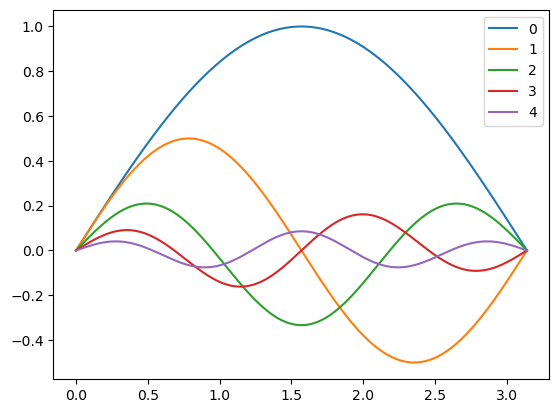

In [4]:
N1=1000;
theta1 = np.linspace(0,np.pi,N1)#different angels inside [0,pi]
for n in range(0,5):
    G = gegenbauer(n, 0.5, monic=True)
    plt.plot(theta1,G(np.cos(theta1))*np.sin(theta1),label=str(n));
plt.legend();

# Distribution base on angle

Point $P$ is inside a sphere centered at the origin $O$ with radius $1$ and denote $r=|P|$. A Brownian motion starting at $P$ hits the surface of the sphere at the random point $X$. Let $\Theta$ be the angel between $OP$ and $OX$. We shall find an approximation of the density of $\Theta$ in dimensions $2$, $3$, and $4$.

References: 

    [1] Madalina Deaconu. Samuel Herrmann. "Hitting time for Bessel processes—walk on moving spheres algorithm (WoMS)." Ann. Appl. Probab. 23 (6) 2259 - 2289, December 2013. https://doi.org/10.1214/12-AAP900
    
    [2] Hsu, Pei. "Brownian exit distribution of a ball." Seminar on Stochastic Processes, 1985. Birkhäuser Boston, 1986.

In [5]:
N=500#ang
Dt=np.pi/N# Delta theta for integration if needed
theta = np.linspace(0,np.pi,N)#different angels inside [0,pi]
M=3#number of ratios
ratio = np.array([n/(n+1) for n in range(0,M)])#np.linspace(0.8,0.9,2)#distance of the starting point to center
K=50#Number of series expansion terms

In [6]:
theta[0],theta[-1]

(0.0, 3.141592653589793)

## Dimension $d=2$

The density of $\Theta$ can be written in terms of the Cebysev polynomials of 1st kind, $T_n$:

$f_{\Theta}(\theta)=\frac{1}{\pi}\Big(1+2\sum_{n=1}^\infty r^n  T_n\big(\cos(\theta)\big)\Big)$, for $\theta\in[0,\pi]$

The integration of densities for different ratios are in [1.0000,1.0032].


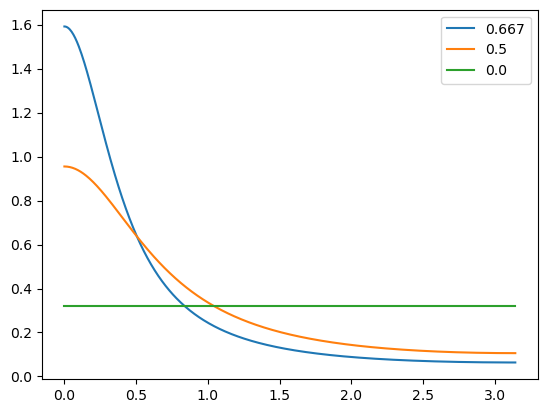

In [7]:
# array to save the density approximation for different values of theta
fct2 = dict(zip(ratio,np.ones(theta.shape[0])/np.pi))# the first term in the series approximatin is 1/pi
for r in ratio:# loop over different distances from origin
    for n in range(0,K):# loop over the orthogonal polynomial order
        T = chebyt(n+1, monic=False)#Cebysev with assumption that leading term is not 1.
#         print(T(1))
        fct2[r]+=np.power(r,n+1)*T(np.cos(theta))*T(1)*2/np.pi #add nth term
# plotting the pdf for some of the ratios
for r in ratio[::-1]:
    plt.plot(theta,fct2[r],label=str(round(r,3)));
plt.legend();    
#verify the densities approximately integrate  to  1
print("The integration of densities for different ratios are in [{:.4f},{:.4f}].".format(np.min(np.array(list(fct2.values())).sum(axis=1)*Dt),np.max(np.array(list(fct2.values())).sum(axis=1)*Dt)));


Term by term integration yieds the cdf:

$F_{\Theta}(\theta)=\frac{1}{\pi}\Big(\theta+2\sum_{n=1}^\infty \frac{r^n}{n} \sin(n\theta)\Big)$, for $\theta\in[0,\pi]$

$F_\Theta(\pi)$ for different values of $r$ ranges from  [1.0000000000e+00,1.0000000000e+00].

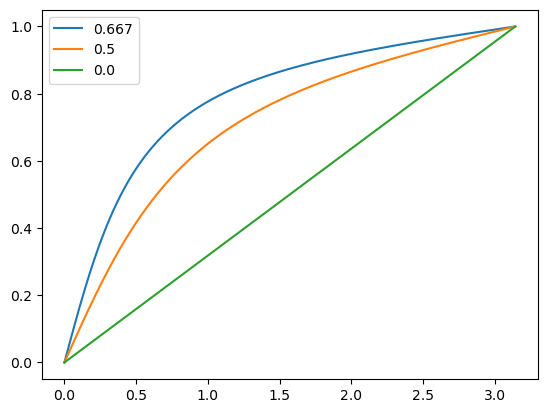

In [8]:
Fct2 = dict(zip(ratio,np.zeros(theta.shape[0])))
for r in ratio:
    Fct2[r]+=theta/np.pi
    for n in range(0,K):
        Fct2[r]+=np.power(r,n+1)*np.sin((n+1)*theta)*2/((n+1)*np.pi)
for r in ratio[::-1]:
    plt.plot(theta,Fct2[r],label=str(round(r,3)));
plt.legend();
error = [np.array(list(Fct2.values()))[n][-1] for n in range(0,len(ratio))]
Markdown("$F_\Theta(\pi)$ for different values of $r$ ranges from  [{:.10e},{:.10e}].".format(np.min(error),np.max(error)))

Because $T_n\big(\cos(\theta)\big)=\cos(n\theta)$, we can also do the following.

$f_{\Theta}(\theta)=\frac{1}{\pi}\Big(1+2\sum_{n=1}^\infty r^n \cos(n\theta)\Big)$, for $\theta\in[0,\pi]$

The integration of densities for different ratios are in [1.00000e+00,1.00320e+00].


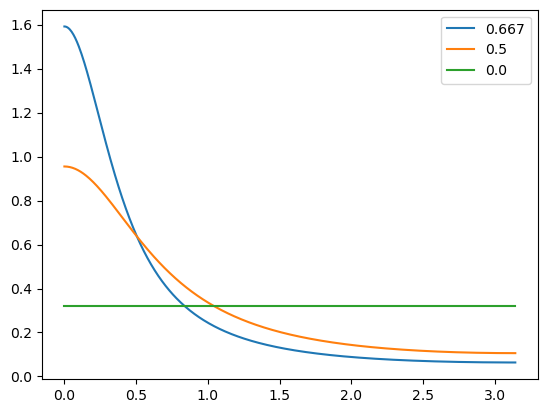

In [9]:
# array to save the density approximation for different values of theta
fg2 = dict(zip(ratio,np.ones(theta.shape[0])/np.pi))# the first term in the series approximatin is 1/pi
for r in ratio:# loop over different distances from origin
    for n in range(0,K):# loop over the orthogonal polynomial order
        fg2[r]+=np.power(r,n+1)*np.cos((n+1)*theta)*2/np.pi #relace T_n\big(\cos(\theta)\big) by \cos(n\theta)
for r in ratio[::-1]:
    plt.plot(theta,fg2[r],label=str(round(r,3)));
print("The integration of densities for different ratios are in [{:.5e},{:.5e}].".format(np.min(np.array(list(fg2.values())).sum(axis=1)*Dt),np.max(np.array(list(fg2.values())).sum(axis=1)*Dt)));
plt.legend();

Or we can manually evaluate the cdf $F_\Theta(\theta)$.

$F_\Theta(\pi)$ for different values of $r$ ranges from  [1.0000000000e+00,1.0032000000e+00].

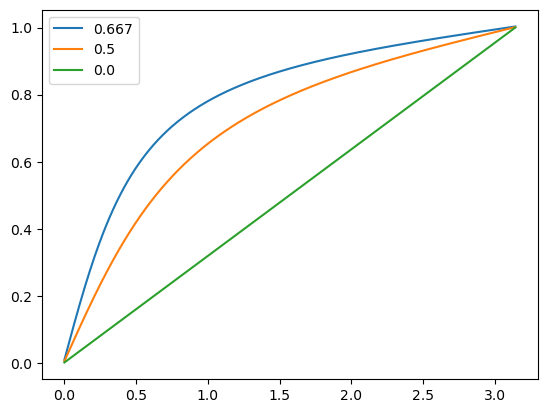

In [10]:
Fg2 = {r:fg2[r].cumsum()*Dt for r in fg2.keys()}
for r in ratio[::-1]:
    plt.plot(theta,Fg2[r],label=str(round(r,3)));
plt.legend();
error = [np.array(list(Fg2.values()))[n][-1] for n in range(0,len(ratio))]
Markdown("$F_\Theta(\pi)$ for different values of $r$ ranges from  [{:.10e},{:.10e}].".format(np.min(error),np.max(error)))

## Dimension $d=3$

The density of $\Theta$ can be written in terms of the Legendre polynomials, $L_n$:

$f_{\Theta}(\theta)=\frac{1}{2}\Big(1+\sum_{n=1}^\infty {r^n} (2n+1)  L_n\big(\cos(\theta)\big)\Big)\sin(\theta)$, for $\theta\in[0,\pi]$

The integration of densities for different ratios are in $[9.97975e-01,9.97997e-01]$.


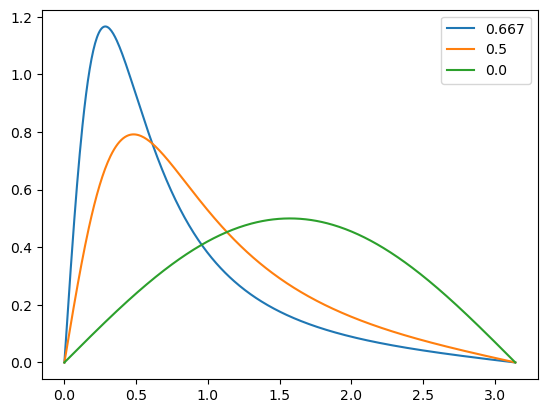

In [11]:
fL3 = {r:np.sin(theta)/2 for r in ratio}
for r in ratio:
    for n in range(0,K+20):
        L = legendre(n+1, monic=False)# Here the coefficients are not monic L(1)=1.
#         print(L(1))
        fL3[r]+=np.power(r,n+1)*L(np.cos(theta))*np.sin(theta)*(2*n+3)*L(1)/2
for r in ratio[::-1]:
    plt.plot(theta,fL3[r],label=str(round(r,3)));
print("The integration of densities for different ratios are in $[{:.5e},{:.5e}]$.".format(np.min(np.array(list(fL3.values())).sum(axis=1)*Dt),np.max(np.array(list(fL3.values())).sum(axis=1)*Dt)));
plt.legend();

$F_\Theta(\pi)$ for different values of $r$ ranges from  $[9.9797507786e-01,9.9799670354e-01]$.

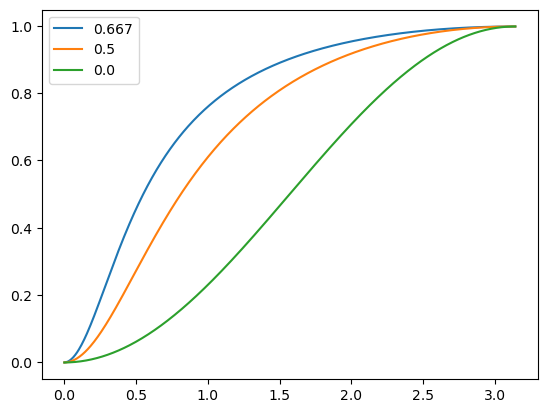

In [12]:
FL3 = {r:fL3[r].cumsum()*Dt for r in fL3.keys()}
for r in ratio[::-1]:
    plt.plot(theta,FL3[r],label=str(round(r,3)));
plt.legend();
error = [np.array(list(FL3.values()))[n][-1] for n in range(0,len(ratio))]
Markdown("$F_\Theta(\pi)$ for different values of $r$ ranges from  $[{:.10e},{:.10e}]$.".format(np.min(error),np.max(error)))

Legenre polynomial is a special case of **Gegenbauer polynomials**. More precisely, $L_n=G_n^{\frac12}$. This is, inparticular, important when we want to generalize to higher dimensions. However, we use this fact for verification of the previous calculations.

The integration of densities for different ratios are in $[9.97975e-01,9.97997e-01]$.

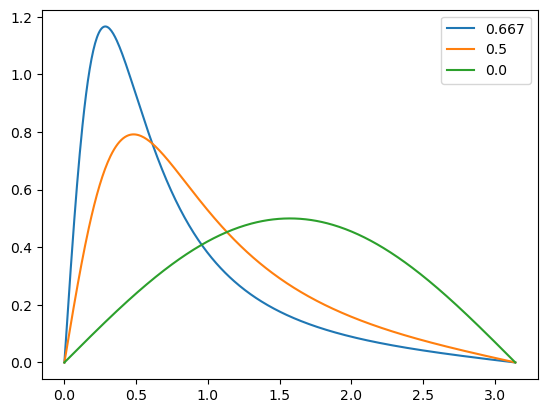

In [13]:
fg3 = {r:np.sin(theta)/2 for r in ratio}
for r in ratio:
    for n in range(0,K+20):
        G = gegenbauer(n+1, 0.5, monic=False)
        # print(G(1))
        fg3[r]+=np.power(r,n+1)*G(np.cos(theta))*np.sin(theta)*(2*n+3)/2
for r in ratio[::-1]:
    plt.plot(theta,fg3[r],label=str(round(r,3)));
plt.legend();    
Markdown("The integration of densities for different ratios are in $[{:.5e},{:.5e}]$.".format(np.min(np.array(list(fg3.values())).sum(axis=1)*Dt),np.max(np.array(list(fg3.values())).sum(axis=1)*Dt)))


We evaluate **cdf** numerially.

Just for demonstration, here is  $G_n^{\frac12}(\cos\theta)\sin(\theta)$ for $n=0,...,4$.

$F_\Theta(\pi)$ for different values of $r$ ranges from  $[9.9797507786e-01,9.9799670354e-01]$.

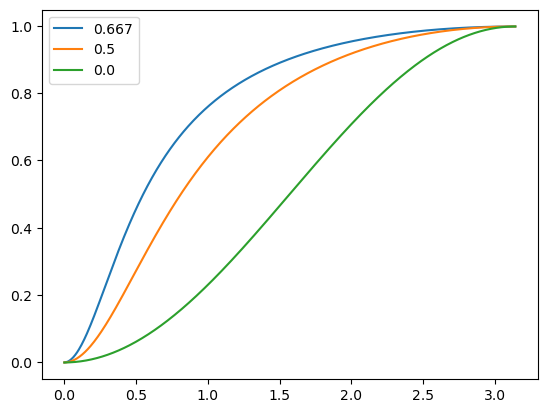

In [14]:
Fg3 = {r:fg3[r].cumsum()*Dt for r in fg3.keys()}
for r in ratio[::-1]:
    plt.plot(theta,Fg3[r],label=str(round(r,3)));
plt.legend();
error = [np.array(list(Fg3.values()))[n][-1] for n in range(0,len(ratio))]
Markdown("$F_\Theta(\pi)$ for different values of $r$ ranges from  $[{:.10e},{:.10e}]$.".format(np.min(error),np.max(error)))

Using Genenbauer polynomials looks more precise compared to Legendre polynomials.

## Dimension $d=4$

The density of $\Theta$ can be written in terms of the Cebysev polynomials of 2nd kind, $U_n$:

$f_{\Theta}(\theta)=\frac{2}{\pi}\Big(1+\sum_{n=1}^\infty r^n  U_n\big(\cos(\theta)\big)\Big)\sin^2(\theta)$, for $\theta\in[0,\pi]$

The integration of densities for different ratios are in $[9.98000e-01,9.98000e-01]$.

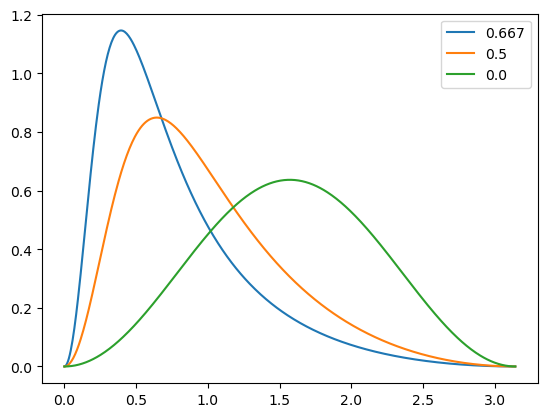

In [15]:
fcu4 = {r:np.sin(theta)*np.sin(theta)*2/np.pi for r in ratio}
for r in ratio:
    for n in range(0,K+30):
        U = chebyu(n+1, monic=False)
#         print(U(1))
        fcu4[r]+=np.power(r,n+1)*U(np.cos(theta))*U(1)*np.sin(theta)*np.sin(theta)*2/(np.pi)
for r in ratio[::-1]:
    plt.plot(theta,fcu4[r],label=str(round(r,3)));
plt.legend();
Markdown("The integration of densities for different ratios are in $[{:.5e},{:.5e}]$.".format(np.min(np.array(list(fcu4.values())).sum(axis=1)*Dt),np.max(np.array(list(fcu4.values())).sum(axis=1)*Dt)))

$F_\Theta(\pi)$ for different values of $r$ ranges from  $[9.9800000000e-01,9.9800000000e-01]$.

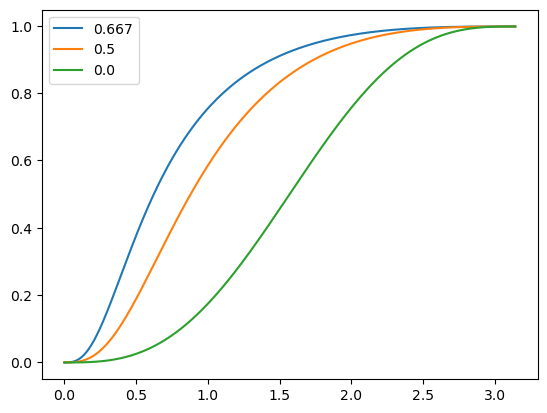

In [16]:
Fcu4 = {r:fcu4[r].cumsum()*Dt for r in fcu4.keys()}
for r in ratio[::-1]:
    plt.plot(theta,Fcu4[r],label=str(round(r,3)));
plt.legend();
error = [np.array(list(Fcu4.values()))[n][-1] for n in range(0,len(ratio))]
Markdown("$F_\Theta(\pi)$ for different values of $r$ ranges from  $[{:.10e},{:.10e}]$.".format(np.min(error),np.max(error)))

Cebysev polynomial of 2nd type are special cases of Gegenbauer polynomials. More precisely, $U_n=G_n^{1}$. We use this fact for verification of the previous calculations.

The integration of densities for different ratios are in $[9.98000e-01,9.98000e-01]$.

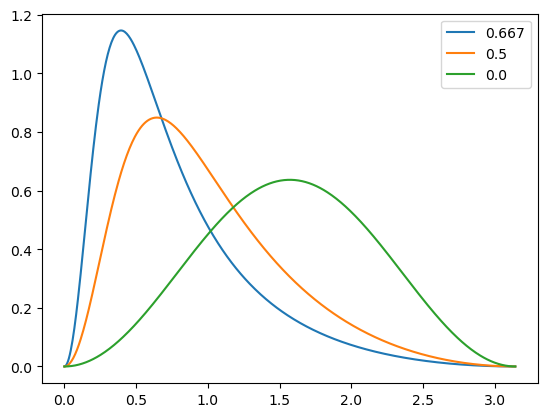

In [17]:
fg4 = {r:np.sin(theta)*np.sin(theta)*2/np.pi for r in ratio}
for r in ratio:
    for n in range(0,K+30):
        G = gegenbauer(n+1, 1, monic=False)
        # print(G(1))
        fg4[r]+=np.power(r,n+1)*G(np.cos(theta))*G(1)*np.sin(theta)*np.sin(theta)*2/(np.pi)
for r in ratio[::-1]:
    plt.plot(theta,fg4[r],label=str(round(r,3)));
plt.legend();
Markdown("The integration of densities for different ratios are in $[{:.5e},{:.5e}]$.".format(np.min(np.array(list(fg4.values())).sum(axis=1)*Dt),np.max(np.array(list(fg4.values())).sum(axis=1)*Dt)))

$F_\Theta(\pi)$ for different values of $r$ ranges from  $[9.9800000000e-01,9.9800000000e-01]$.

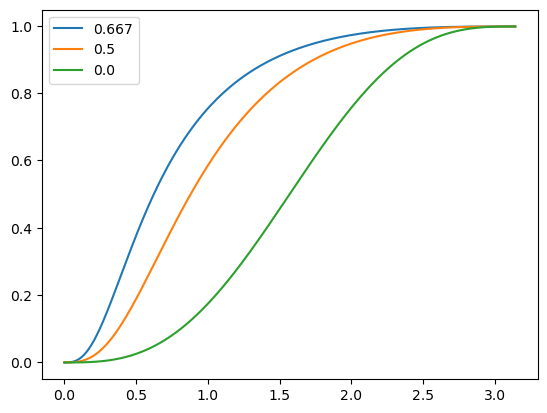

In [18]:
Fg4 = {r:fg4[r].cumsum()*Dt for r in fg4.keys()}
for r in ratio[::-1]:
    plt.plot(theta,Fg4[r],label=str(round(r,3)));
plt.legend();
error = [np.array(list(Fg4.values()))[n][-1] for n in range(0,len(ratio))]
Markdown("$F_\Theta(\pi)$ for different values of $r$ ranges from  $[{:.10e},{:.10e}]$.".format(np.min(error),np.max(error)))

## Dimension $d=5$

The density of $\Theta$ can be written in terms of the Cebysev polynomials of 2nd kind, $U_n$:

$f_{\Theta}(\theta)=\Big(\frac{3}{4}+\sum_{n=1}^\infty r^n\frac{2n+3}{2(n+2)(n+1)}  G^{3/2}_n(1)G^{3/2}_n\big(\cos(\theta)\big)\Big)\sin^3(\theta)$, for $\theta\in[0,\pi]$

/Users/fahim/opt/anaconda3/lib/python3.11/site-packages/scipy/special/_orthogonal.py:133: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))


The integration of densities for different ratios are in $[9.98000e-01,9.98000e-01]$.

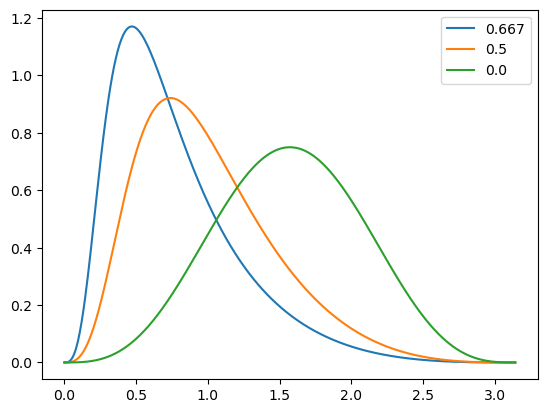

In [19]:
fg5 = {r:np.sin(theta)*np.sin(theta)*np.sin(theta)*3/4 for r in ratio}
for r in ratio:
    for n in range(0,K+50):
        G = gegenbauer(n+1, 1.5, monic=False)
#         print(G(1))
        fg5[r]+=np.power(r,n+1)*G(np.cos(theta))*G(1)*np.sin(theta)*np.sin(theta)*np.sin(theta)*(2*n+5)/(2*(n+3)*(n+2))
for r in ratio[::-1]:
    plt.plot(theta,fg5[r],label=str(round(r,3)));
plt.legend();
Markdown("The integration of densities for different ratios are in $[{:.5e},{:.5e}]$.".format(np.min(np.array(list(fg5.values())).sum(axis=1)*Dt),np.max(np.array(list(fg5.values())).sum(axis=1)*Dt)))

$F_\Theta(\pi)$ for different values of $r$ ranges from  $[9.9800000002e-01,9.9800000132e-01]$.

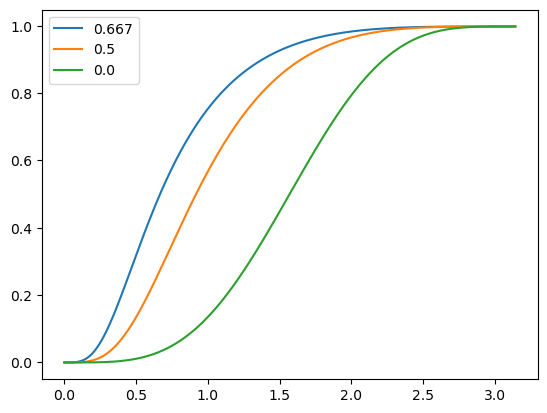

In [20]:
Fg5 = {r:fg5[r].cumsum()*Dt for r in fg5.keys()}
for r in ratio[::-1]:
    plt.plot(theta,Fg5[r],label=str(round(r,3)));
plt.legend();
error = [np.array(list(Fg5.values()))[n][-1] for n in range(0,len(ratio))]
Markdown("$F_\Theta(\pi)$ for different values of $r$ ranges from  $[{:.10e},{:.10e}]$.".format(np.min(error),np.max(error)))

## Comparison

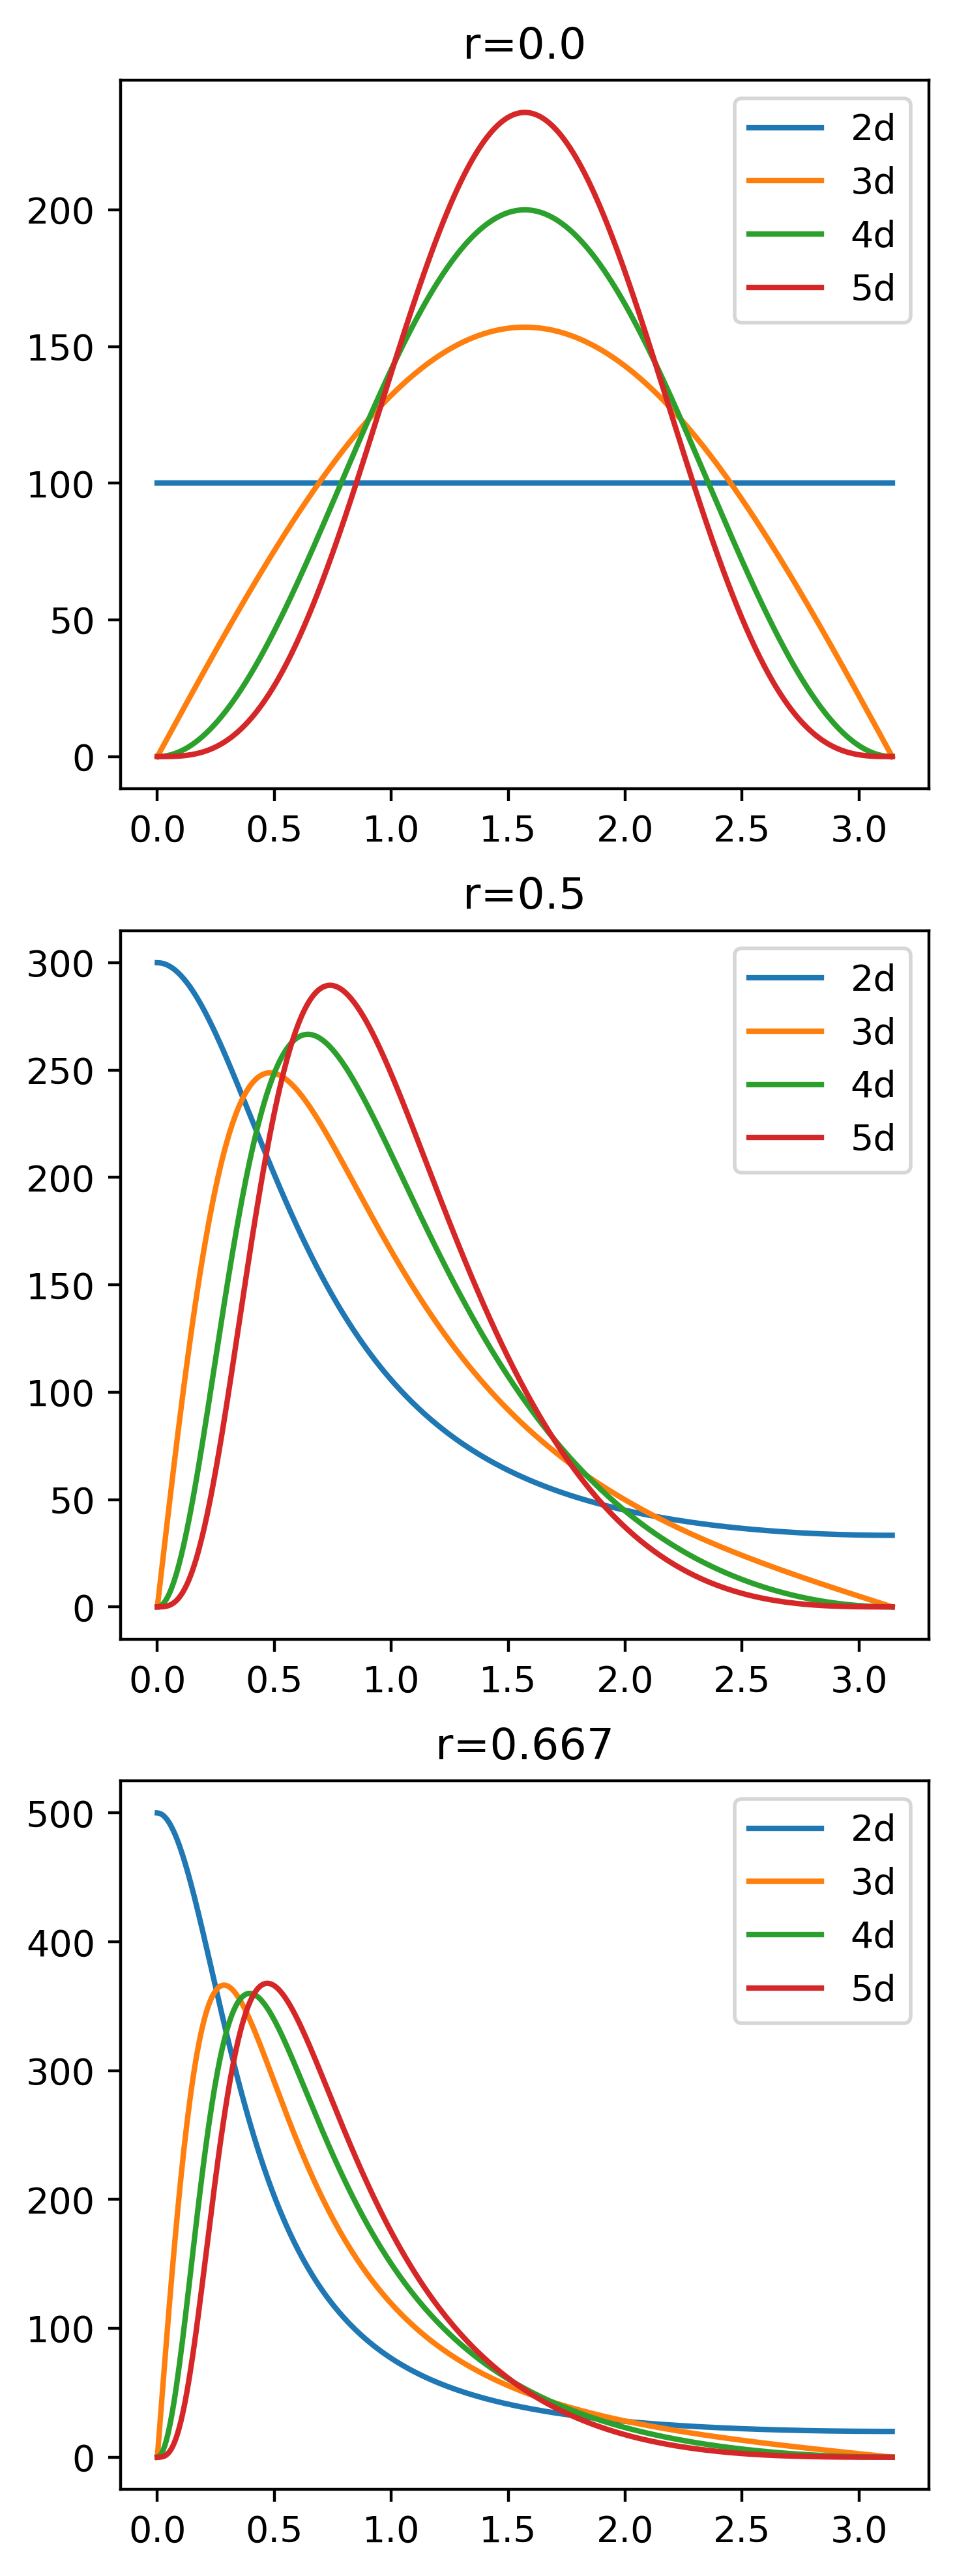

In [21]:
f , ax = plt.subplots(M,1,figsize=(4,4*M),dpi=400);
for i, r in enumerate(ratio):
    ax[i].plot(theta,fg2[r]*10000/100*np.pi,label="2d");
    ax[i].plot(theta,fL3[r]*10000/100*np.pi,label="3d");
    ax[i].plot(theta,fcu4[r]*10000/100*np.pi,label="4d");
    ax[i].plot(theta,fg5[r]*10000/100*np.pi,label="5d");
    ax[i].set_title("r="+str(round(r,3)))
    ax[i].legend();

# Distribution base on coordinates

A Brownian motion starting at $P$ hits the surface of the sphere at the random point $X$. Recall that we derived the distribution of $\Theta$, the angel between $OP$ and $OX$. We know write the distribution of $Z=\cos(\Theta)$, which we consider it as the last coordinate of the point $P$.

In [22]:
Nz=500
Dz=2/Nz# Delta theta for integration if needed
z = np.linspace(-0.999,0.999,N)#range of \cos(\theta) [-1,1]

## Dimension $d=2$

The density of the last coordinat $Z$ can be written in terms of the Cebysev polynomials of 1st kind, $T_n$:

$f_{Z}(z)=\frac{1}{\pi\sqrt{1-z^2}}\Big(1+2\sum_{n=1}^\infty r^n  T_n\big(z\big)\Big)$, for $z\in[-1,1]$

The integration of densities for different ratios are in [1.0059,1.0112].


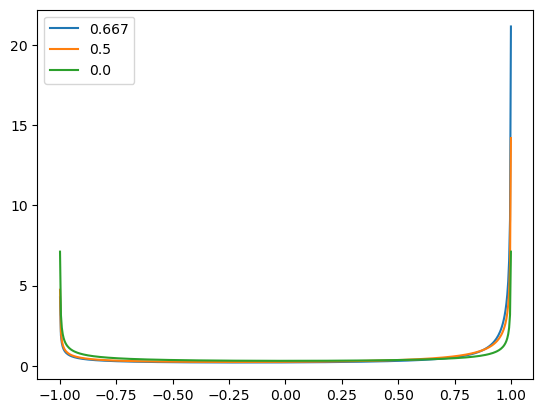

In [23]:
# array to save the density approximation for different values of theta
f02 = [1/(np.pi*np.sqrt(1-z*z)) for r in ratio]
fctz2 = dict(zip(ratio,f02))# the first term in the series approximatin is 1/pi
for r in ratio:# loop over different distances from origin
    for n in range(0,K):# loop over the orthogonal polynomial order
        T = chebyt(n+1, monic=False)#Cebysev with assumption that leading term is not 1.
#         print(T(1))
        fctz2[r]+=np.power(r,n+1)*T(z)*T(1)/(np.pi*np.sqrt(1-z*z)) #add nth term
# plotting the pdf for some of the ratios
for r in ratio[::-1]:
    plt.plot(z,fctz2[r],label=str(round(r,3)));
plt.legend();    
#verify the densities approximately integrate  to  1
print("The integration of densities for different ratios are in [{:.4f},{:.4f}].".format(np.min(np.array(list(fctz2.values())).sum(axis=1)*Dz),np.max(np.array(list(fctz2.values())).sum(axis=1)*Dz)));


## Dimension $d=3$

The density of $\Theta$ can be written in terms of the Legendre polynomials, $L_n$:

$f_{Z}(z)=\frac{1}{2}\Big(1+\sum_{n=1}^\infty {r^n} (2n+1)  L_n\big(z\big)\Big)$, for $z\in[-1,1]$

In [24]:
Nz=500
Dz=2/Nz# Delta theta for integration if needed
z = np.linspace(-1,1,N)#range of z in [-1,1]

The integration of densities for different ratios are in $[1.00000e+00,1.01330e+00]$.


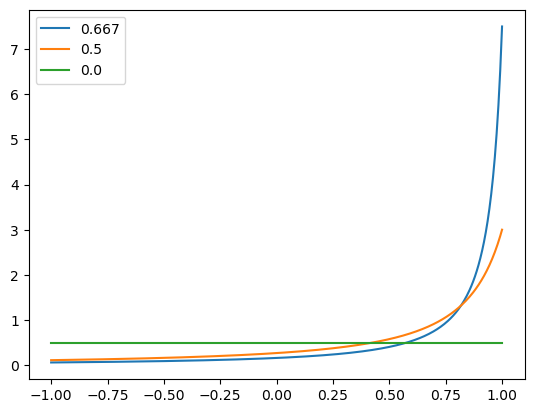

In [25]:
# array to save the density approximation for different values of theta
f03 = [np.ones(z.shape)*0.5 for r in ratio]
fLz3 = dict(zip(ratio,f03))# the first term in the series approximatin is 1/pifor r in ratio:
for r in ratio:# loop over different distances from origin
    for n in range(0,K+20):
        L = legendre(n+1, monic=False)# Here the coefficients are not monic L(1)=1.
    #     print(L(1))
        fLz3[r]+=np.power(r,n+1)*L(z)*(2*n+3)*L(1)/2
for r in ratio[::-1]:
    plt.plot(z,fLz3[r],label=str(round(r,3)));
print("The integration of densities for different ratios are in $[{:.5e},{:.5e}]$.".format(np.min(np.array(list(fLz3.values())).sum(axis=1)*Dz),np.max(np.array(list(fLz3.values())).sum(axis=1)*Dz)));
plt.legend();

$F_Z(z)$ for different values of $r$ ranges from  $[1.0000000000e+00,1.0133002422e+00]$.

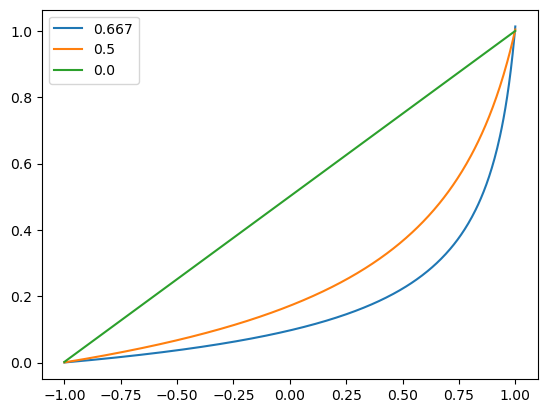

In [26]:
FLz3 = {r:fLz3[r].cumsum()*Dz for r in fLz3.keys()}
for r in ratio[::-1]:
    plt.plot(z,FLz3[r],label=str(round(r,3)));
plt.legend();
error = [np.array(list(FLz3.values()))[n][-1] for n in range(0,len(ratio))]
Markdown("$F_Z(z)$ for different values of $r$ ranges from  $[{:.10e},{:.10e}]$.".format(np.min(error),np.max(error)))

## Dimension $d=4$

The density of $Z$ can be written in terms of the Cebysev polynomials of 2nd kind, $U_n$:

$f_{Z}(x)=\frac{2\sqrt{1-z^2}}{\pi}\Big(1+\sum_{n=1}^\infty r^n  U_n\big(z\big)\Big)$, for $z\in[-1,1]$

In [27]:
Nz=500
Dz=2/Nz# Delta theta for integration if needed
z = np.linspace(-1,1,N)#range of z in [-1,1]

The integration of densities for different ratios are in $[9.95890e-01,9.97905e-01]$.

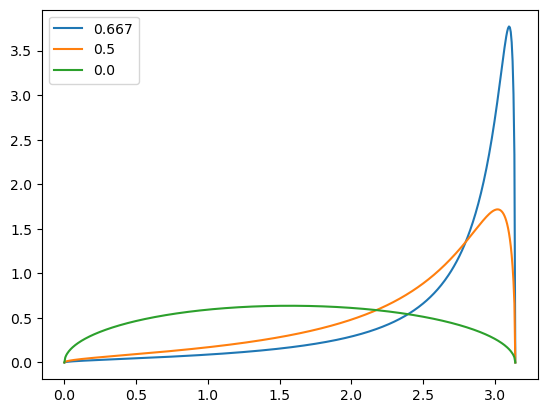

In [28]:
fcuz4 = {r:np.sqrt(1-z*z)*2/np.pi for r in ratio}
for r in ratio:
    for n in range(0,K+30):
        U = chebyu(n+1, monic=False)
#         print(U(1))
        fcuz4[r]+=np.power(r,n+1)*U(z)*U(1)*np.sqrt(1-z*z)*2/(np.pi)
for r in ratio[::-1]:
    plt.plot(theta,fcuz4[r],label=str(round(r,3)));
plt.legend();
Markdown("The integration of densities for different ratios are in $[{:.5e},{:.5e}]$.".format(np.min(np.array(list(fcuz4.values())).sum(axis=1)*Dz),np.max(np.array(list(fcuz4.values())).sum(axis=1)*Dz)))

$F_\Theta(\pi)$ for different values of $r$ ranges from  $[9.9588975402e-01,9.9790521880e-01]$.

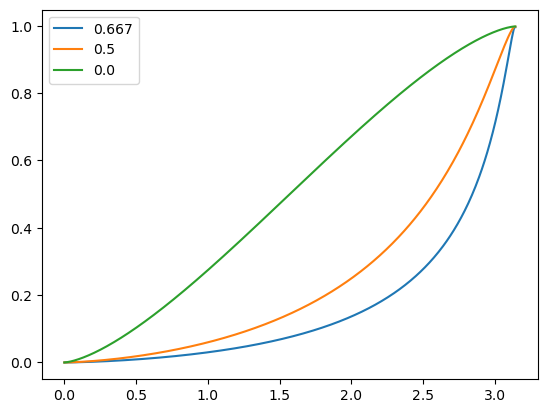

In [29]:
Fcuz4 = {r:fcuz4[r].cumsum()*Dz for r in fcuz4.keys()}
for r in ratio[::-1]:
    plt.plot(theta,Fcuz4[r],label=str(round(r,3)));
plt.legend();
error = [np.array(list(Fcuz4.values()))[n][-1] for n in range(0,len(ratio))]
Markdown("$F_\Theta(\pi)$ for different values of $r$ ranges from  $[{:.10e},{:.10e}]$.".format(np.min(error),np.max(error)))

## Dimension $d=5$

The density of $Z=\cos(\Theta)$ can be written in terms of the Cebysev polynomials of 2nd kind, $U_n$:

$f_{Z}(z)=(1-z^2)\Big(\sum_{n=0}^\infty r^n G^{3/2}_n(1) \frac{2n+3}{2(n+2)(n+1)} G^{3/2}_n\big(z\big)\Big)$, for $z\in[1-,1]$

In [30]:
Nz=500
Dz=2/Nz# Delta theta for integration if needed
z = np.linspace(-1,1,N)#range of z in [-1,1]

The integration of densities for different ratios are in $[9.97730e-01,9.97996e-01]$.

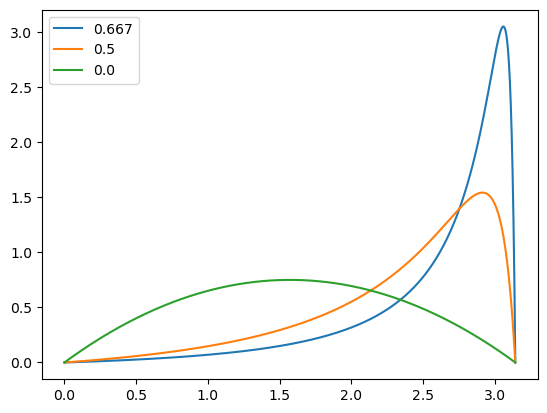

In [31]:
fgz5 = {r:(1-z*z)*3/4 for r in ratio}
for r in ratio:
    for n in range(0,K+50):
        G = gegenbauer(n+1, 1.5, monic=False)
        # print(G(1))
        fgz5[r]+=np.power(r,n+1)*G(z)*G(1)*(1-z*z)*(2*n+5)/(2*(n+3)*(n+2))
for r in ratio[::-1]:
    plt.plot(theta,fgz5[r],label=str(round(r,3)));
plt.legend();
Markdown("The integration of densities for different ratios are in $[{:.5e},{:.5e}]$.".format(np.min(np.array(list(fgz5.values())).sum(axis=1)*Dz),np.max(np.array(list(fgz5.values())).sum(axis=1)*Dz)))

$F_\Theta(\pi)$ for different values of $r$ ranges from  $[1.5672300725e+00,1.5676484384e+00]$.

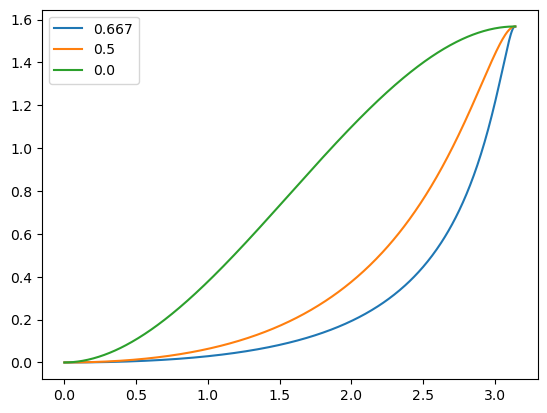

In [32]:
Fgz5 = {r:fgz5[r].cumsum()*Dt for r in fgz5.keys()}
for r in ratio[::-1]:
    plt.plot(theta,Fgz5[r],label=str(round(r,3)));
plt.legend();
error = [np.array(list(Fgz5.values()))[n][-1] for n in range(0,len(ratio))]
Markdown("$F_\Theta(\pi)$ for different values of $r$ ranges from  $[{:.10e},{:.10e}]$.".format(np.min(error),np.max(error)))

# Tests

## Inversion method

In [33]:
#Simulation through inverse cdf
def invF(u,r,F):
    if type(u)==float:
        u = np.array([u])
    i = np.argmin(np.abs(r-ratio))
    temp = []
    for u_ in u:
        # print(np.min(np.where(F[ratio[i]]>=u_)))
        x = F[ratio[i]].shape[0]-1 if np.where(F[ratio[i]]>=u_)[0].size==0 else np.min(np.where(F[ratio[i]]>=u_)) 
        temp.append(x) 
    # print(len(temp),theta.shape)
    return theta[temp]


$d=2$ and $r=0.50$

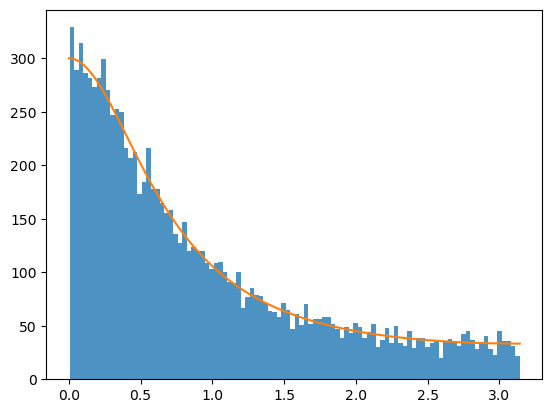

In [34]:
#Change uniform[0,1] to [0,max_F]
i = np.argmin(np.abs(0.5001-ratio))
b = Fct2[ratio[i]].max()
# print("{:.6f}".format(b))
plt.hist(invF(np.random.uniform(0,b,10000),0.5002,Fct2),bins=100,alpha=0.8);
plt.plot(theta,fct2[ratio[i]]*10000/100*np.pi,label=str(round(ratio[i],3)));
Markdown("$d=2$ and $r={:.2f}$".format(ratio[i]))

$d=2$ and $r=0.67$

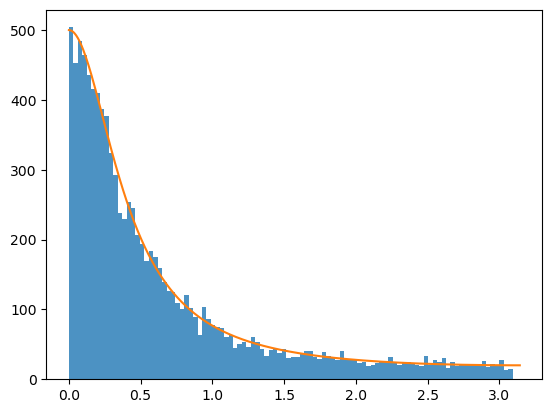

In [35]:
i = np.argmin(np.abs(0.802-ratio))
b = Fg2[ratio[i]].max()
plt.hist(invF(np.random.uniform(0,1,10000),0.802,Fg2),bins=100,alpha=0.8);
plt.plot(theta,fg2[ratio[i]]*10000/100*np.pi,label=str(round(ratio[i],3)));
Markdown("$d=2$ and $r={:.2f}$".format(ratio[i]))

$d=3$ and $r=0.50$

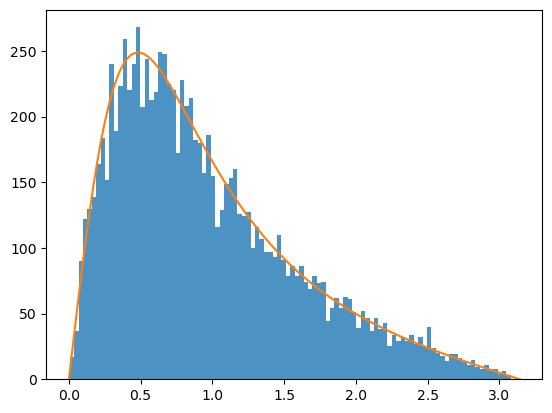

In [64]:
i = np.argmin(np.abs(0.5001-ratio))
b = FL3[ratio[i]].max()
plt.hist(invF(np.random.uniform(0,b,10000),0.5,FL3),bins=100,alpha=0.8);
plt.plot(theta,fL3[ratio[i]]*10000/100*np.pi,label=str(round(ratio[i],3)));
Markdown("$d=3$ and $r={:.2f}$".format(ratio[i]))

In [37]:
x = invF(np.random.uniform(0,1,100000),0.5,FL3)
Markdown("**Error = ${:.2f}\%$**".format(x[x==x.max()].size/1000))

**Error = $0.19\%$**

**Generating $U[0,0.99799]$ gets rid of the error at $\pi$.**

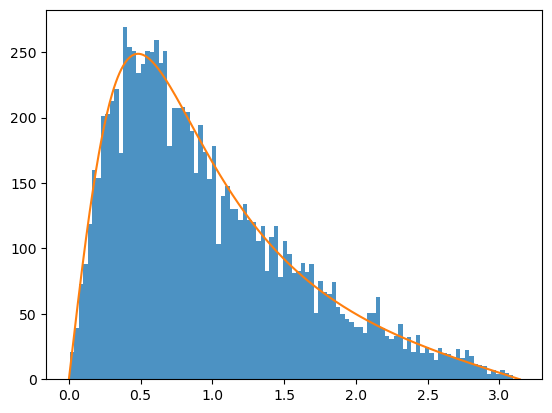

In [38]:
#Change uniform[0,1] to [0,max_F]
i = np.argmin(np.abs(0.5001-ratio))
b = FL3[ratio[i]].max()
plt.hist(invF(np.random.uniform(0,b,10000),0.5,FL3),bins=100,alpha=0.8);
plt.plot(theta,fL3[ratio[i]]*10000/100*np.pi,label=str(round(ratio[i],3)));
Markdown("$d=3$ and $r={:.2f}$".format(ratio[i]))
Markdown("**Generating $U[0,{:.5f}]$ gets rid of the error at $\pi$.**".format(b))

$d=3$ and $r=0.67$

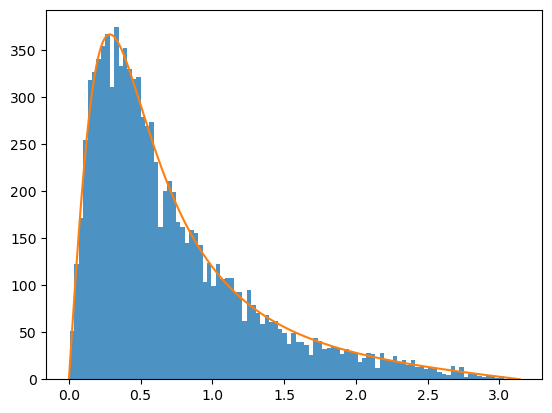

In [39]:
i = np.argmin(np.abs(0.671-ratio))
b = Fg3[ratio[i]].max()
plt.hist(invF(np.random.uniform(0,b,10000),0.671,Fg3),bins=100,alpha=0.8);
plt.plot(theta,fg3[ratio[i]]*10000/100*np.pi,label=str(round(ratio[i],3)));
Markdown("$d=3$ and $r={:.2f}$".format(ratio[i]))

$d=4$ and $r=0.50$

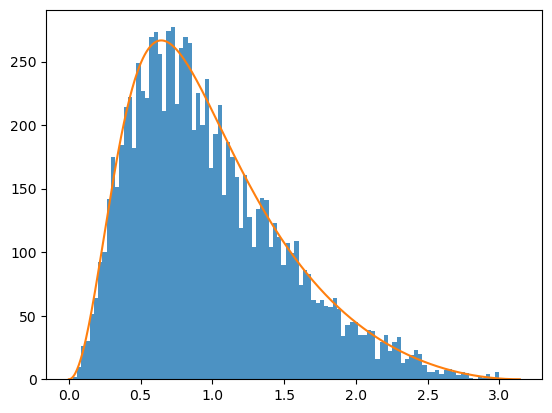

In [40]:
i = np.argmin(np.abs(0.5001-ratio))
b= Fcu4[ratio[i]].max()
plt.hist(invF(np.random.uniform(0,b,10000),0.5,Fcu4),bins=100,alpha=0.8);
plt.plot(theta,fcu4[ratio[i]]*10000/100*np.pi,label=str(round(ratio[i],3)));
Markdown("$d=4$ and $r={:.2f}$".format(ratio[i]))

In [41]:
x = invF(np.random.uniform(0,1,10000),0.5,Fcu4)
Markdown("**Error = ${:.2f}\%$**".format(x[x==x.max()].size/100))

**Error = $0.17\%$**

$d=5$ and $r=0.50$

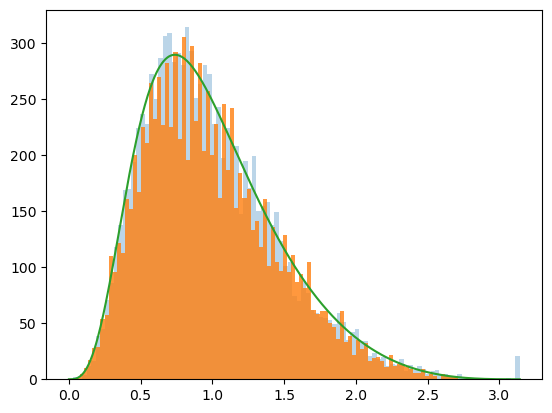

In [42]:
i = np.argmin(np.abs(0.5001-ratio))
b= Fg5[ratio[i]].max()
plt.hist(invF(np.random.uniform(0,1,10000),0.5,Fg5),bins=100,alpha=0.3);
plt.hist(invF(np.random.uniform(0,b,10000),0.5,Fg5),bins=100,alpha=0.8);
plt.plot(theta,fg5[ratio[i]]*10000/100*np.pi,label=str(round(ratio[i],3)));
Markdown("$d=5$ and $r={:.2f}$".format(ratio[i]))

In [43]:
x = invF(np.random.uniform(0,1,10000),0.5,Fg5)
Markdown("**Error = ${:.2f}\%$**".format(x[x==x.max()].size/100))

**Error = $0.19\%$**

If Brownian motion startes at the cener, then $\frac{X}{|X|}$ is a uniform point on the surface of $S^{d+1}$, wehre $X$ is $d+1$-dimensional standard normal random varaible.

**In dimension 3 or above, there is a error near $\pi$. There must not be a bar in there. It is because the pdf is flat near $\pi$.**

## Comparison with $r=0$

$d=3$ and $r=0$

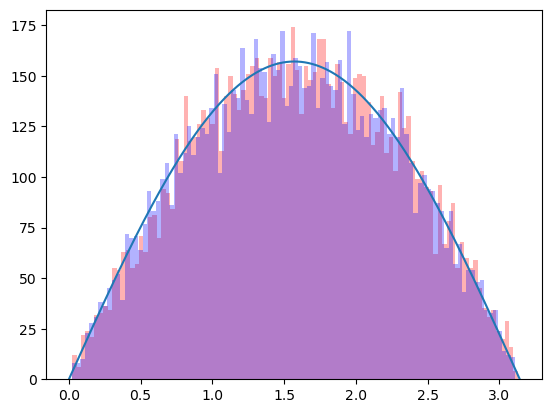

In [61]:
U = np.random.normal(0,1,(10000,3))
L = np.sqrt((U**2).sum(axis=1))
# U = U/L
for i in range(3):
    U[:,i] = U[:,i]/L
# print((U**2).sum(axis=1))
plt.hist(np.arccos(U[:,0]),bins=100,alpha=0.3,color='red');
plt.plot(theta,np.sin(theta)/2*(np.pi/100)*10000);#f(theta)*Delta theta*number of samples
b= FL3[ratio[i]].max()
plt.hist(invF(np.random.uniform(0,b,10000),0.0,FL3),bins=100,alpha=0.3,color='blue');
Markdown("$d=3$ and $r=0$")

$d=4$ and $r=0$

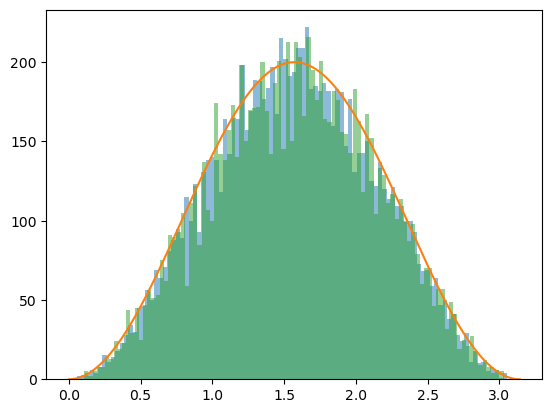

In [62]:
U = np.random.normal(0,1,(10000,4))
L = np.sqrt((U**2).sum(axis=1))
# U = U/L
for i in range(3):
    U[:,i] = U[:,i]/L
# print((U**2).sum(axis=1))
plt.hist(np.arccos(U[:,0]),bins=100,alpha=0.5);
plt.plot(theta,np.sin(theta)*np.sin(theta)*2/np.pi*(np.pi/100)*10000);#f(theta)*Delta theta*number of samples
b= Fcu4[ratio[i]].max()
plt.hist(invF(np.random.uniform(0,b,10000),0.0,Fcu4),bins=100,alpha=0.5);
Markdown("$d=4$ and $r=0$")

$d=5$ and $r=0$

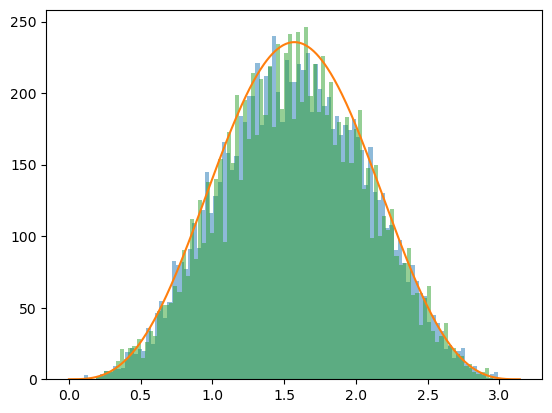

In [63]:
U = np.random.normal(0,1,(10000,5))
L = np.sqrt((U**2).sum(axis=1))
# U = U/L
for i in range(3):
    U[:,i] = U[:,i]/L
# print((U**2).sum(axis=1))
plt.hist(np.arccos(U[:,0]),bins=100,alpha=0.5);
plt.plot(theta,np.sin(theta)*np.sin(theta)*np.sin(theta)*3/4*(np.pi/100)*10000);#f(theta)*Delta theta*number of samples
b= Fg5[ratio[i]].max()
plt.hist(invF(np.random.uniform(0,b,10000),0.0,Fg5),bins=100,alpha=0.5);
Markdown("$d=5$ and $r=0$")

## Acceptance-rejection (not fast enough)

In [47]:
f_5 = lambda theta: np.sin(theta)*np.sin(theta)*np.sin(theta)*3/4
Normal = lambda theta: np.exp(-(theta-np.pi/2)*(theta-np.pi/2)/2)

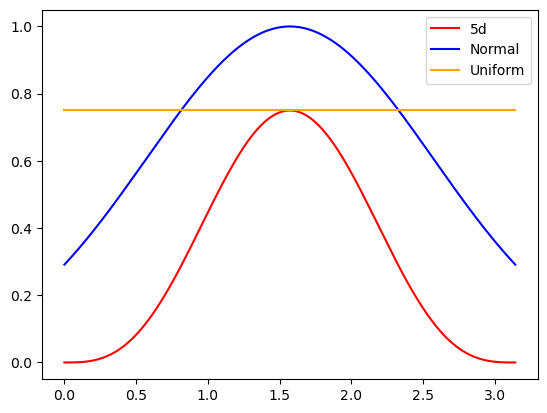

In [48]:
plt.plot(theta,np.sin(theta)*np.sin(theta)*np.sin(theta)*3/4,color='r',label="5d");#f(theta)*Delta theta*number of samples
plt.plot(theta,np.exp(-(theta-np.pi/2)*(theta-np.pi/2)/2),color='b',label="Normal");#Normal
plt.plot(theta,np.ones(theta.shape)*0.75,color='orange',label="Uniform");#Uniform
plt.legend();

In [49]:
def accept_reject_n_5(): 
    x = np.random.normal(0,1)
    return x if ((x<=np.pi)&(x>=0)&(np.random.uniform(0,Normal(x))<=f_5(x))) else None

In [50]:
def accept_reject_u_5(): 
    x = np.random.uniform(0,np.pi)
    return x if np.random.uniform(0,0.75)<=f_5(x) else None

In [51]:
samples_n=[]
for i in range(100000):
    x = accept_reject_n_5()
    if x:
        samples_n.append(x)

In [52]:
len(samples_n)

15582

In [53]:
samples_u=[]
for i in range(100000):
    x = accept_reject_u_5()
    if x:
        samples_u.append(x)

In [54]:
len(samples_u)

42488

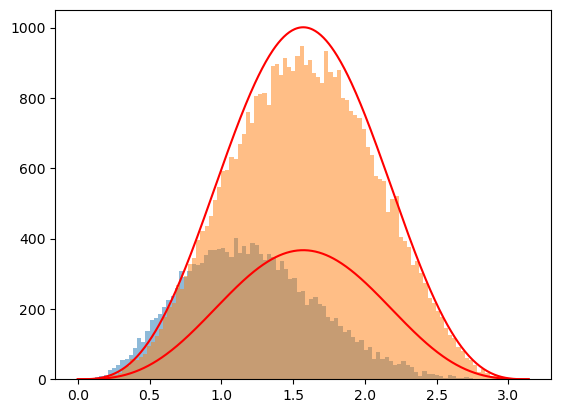

In [55]:
plt.hist(samples_n,bins=100,alpha=0.5);
plt.hist(samples_u,bins=100,alpha=0.5);
plt.plot(theta,np.sin(theta)*np.sin(theta)*np.sin(theta)*3/4*len(samples_u)*(np.pi/100),color='r',label="5d");#f(theta)*Delta theta*number of samples
plt.plot(theta,np.sin(theta)*np.sin(theta)*np.sin(theta)*3/4*len(samples_n)*(np.pi/100),color='r',label="5d");#f(theta)*Delta theta*number of samples

In [56]:
def f_5(r,theta):
    f = np.sin(theta)*np.sin(theta)*np.sin(theta)*3/4
    for n in range(0,K+50):
        G = gegenbauer(n+1, 1.5, monic=False)
#         print(G(1))
        f+=np.power(r,n+1)*G(np.cos(theta))*G(1)*np.sin(theta)*np.sin(theta)*np.sin(theta)*(2*n+5)/(2*(n+3)*(n+2))
    return f

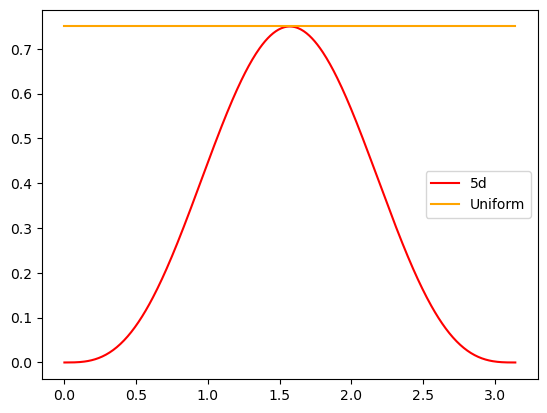

In [57]:
f = f_5(0,theta)
fmax = max(f)
plt.plot(theta,f,color='r',label="5d");#f(theta)*Delta theta*number of samples
plt.plot(theta,np.ones(theta.shape)*fmax,color='orange',label="Uniform");#Uniform
plt.legend();